<a href="https://colab.research.google.com/github/JWasonga/Statistical-Data-Analytics/blob/main/Timeseries_Analysis_using_ARIMA_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**The Dataset: Kenya Economic Growth Indicators**

The dataset  presents economics growth indicators; GDP in current US dollars, GCF in current US dollars and Labor as population proxy from 1991 to present from official World Bank data repository

#**Data Loading and Importing Necessary Libraries**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving transposed.xlsx to transposed.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
%matplotlib inline

In [4]:
df = pd.read_excel("transposed.xlsx")
df.head()

,year,gdp,gcf,labor
0,1990,8572359168,2071432832,73.783
1,1991,8151489024,1709409152,73.723
2,1992,8209120768,1389052160,73.657
3,1993,5751786496,1012914624,73.588
4,1994,7148148736,1379109632,73.518


# **Exploratory Data Analysis (EDA)**

In [5]:
df.shape

(35, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    35 non-null     int64  
 1   gdp     35 non-null     int64  
 2   gcf     35 non-null     int64  
 3   labor   35 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 1.2 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,35.0,2.007000e+03,1.024695e+01,1.990000e+03,1.998500e+03,2.007000e+03,2.015500e+03,2.024000e+03
gdp,35.0,4.498477e+10,3.810350e+10,5.751786e+09,1.294101e+10,3.195819e+10,7.246780e+10,1.203396e+11
gcf,35.0,8.820464e+09,7.457712e+09,1.012915e+09,2.036538e+09,6.537681e+09,1.622531e+10,2.236994e+10
labor,35.0,7.264403e+01,2.286523e+00,6.744800e+01,7.321450e+01,7.351800e+01,7.387000e+01,7.469700e+01


In [8]:
df.isnull().sum()

,0
year,0
gdp,0
gcf,0
labor,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns.tolist()

['year', 'gdp', 'gcf', 'labor']

#**Plotting the Trends of GCF, GDP and Labor Series**

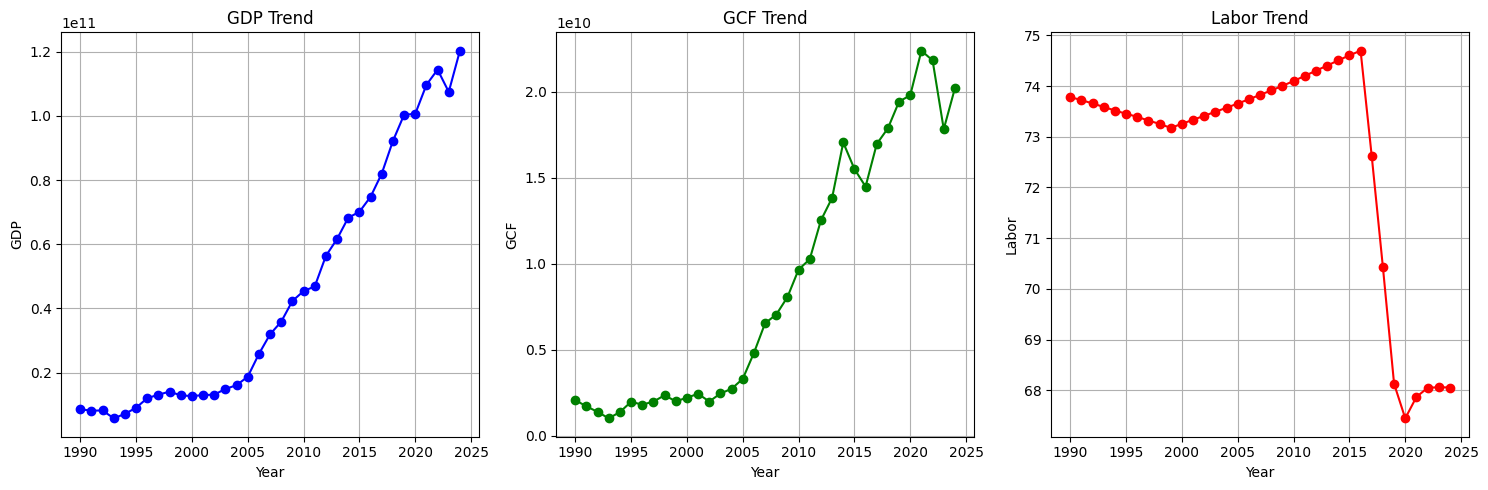

In [30]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(df['year'], df['gdp'], marker='o', linestyle='-', color='b')
plt.title('GDP Trend')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(df['year'], df['gcf'], marker='o', linestyle='-', color='g')
plt.title('GCF Trend')
plt.xlabel('Year')
plt.ylabel('GCF')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(df['year'], df['labor'], marker='o', linestyle='-', color='r')
plt.title('Labor Trend')
plt.xlabel('Year')
plt.ylabel('Labor')
plt.grid(True)

plt.tight_layout()
plt.show()


### *Interpretation of Trends*

From the plots of the feature series, we can observe the following trends:

*   **GDP (Gross Domestic Product):** The GDP series shows a clear upward trend over the years, indicating overall economic growth. There are some fluctuations, but the general direction is positive.

*   **GCF (Gross Capital Formation):** Similar to GDP, GCF also exhibits an increasing trend, suggesting a rise in investment within the economy over time. This often correlates with economic expansion.

*   **Labor:** The Labor series, which is used as a population proxy, also displays an upward trend, indicating an increase in the labor force or population over the period. This is a common characteristic of developing economies.

All three series show non-stationary behavior with evident trends, which is why differencing was necessary for time series modeling.

#**Checking For Stationarity for GDP, GCF, and Labor**

## **Part one : GDP**

In [39]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['gdp'])
print('ADF test for GDP series')
print('ADF test Statistic', result[0])
print('p-value:', result[1])

ADF test for GDP series
ADF test Statistic 2.4723539949978037
p-value: 0.999040389773701


In [15]:
df_diff = df['gdp'].diff()
df_diff = df_diff.dropna()

result = adfuller(df_diff)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.9656261730930669
p-value: 0.3018451445422593


In [16]:
df_diff2 = df_diff.diff()
df_diff2 = df_diff2.dropna()

result = adfuller(df_diff2)
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -8.569145372670379
p-value: 8.288486016424974e-14


### *Interpretation of GDP Stationarity Tests*

*   ** GDP Series:** The ADF test on the gdp series resulted in a high p-value (e.g., 0.999), which is much greater than the common significance level of 0.05. This indicates that the original gdp series is **non-stationary** and exhibits a trend, as visually confirmed in the earlier plots.

*   **First-Differenced GDP Series :** After applying first-order differencing, the ADF test still yielded a p-value greater than 0.05 (e.g., 0.301). This suggests that the first-differenced series is **still non-stationary**, meaning that one differencing step was not sufficient to remove the trend.

*   **Second-Differenced GDP Series :** Upon applying a second-order differencing (df_diff2), the ADF test produced a very low p-value (e.g., 8.288e-14), which is significantly less than 0.05. This result indicates that the second-differenced gdp series is now **stationary**. This means that for the purpose of ARIMA modeling, the gdp series requires a differencing order I(2) to achieve stationarity.

##**Part Two : GCF and Labor**

In [35]:
print('ADF Test for GCF series')
result_gcf = adfuller(df['gcf'])
print('ADF Statistic:', result_gcf[0])
print('p-value:', result_gcf[1])

print('\n ADF Test for Labor series')
result_labor = adfuller(df['labor'])
print('ADF Statistic:', result_labor[0])
print('p-value:', result_labor[1])


ADF Test for GCF series
ADF Statistic: -1.7157718750368438
p-value: 0.4230051997515219

 ADF Test for Labor series
ADF Statistic: -3.587911264844197
p-value: 0.005996388774867126


In [34]:
df_gcf_diff = df['gcf'].diff().dropna()
df_labor_diff = df['labor'].diff().dropna()

print('ADF Test for first-differenced GCF series')
result_gcf_diff = adfuller(df_gcf_diff)
print('ADF Statistic:', result_gcf_diff[0])
print('p-value:', result_gcf_diff[1])

print('\n ADF Test for first-differenced Labor series')
result_labor_diff = adfuller(df_labor_diff)
print('ADF Statistic:', result_labor_diff[0])
print('p-value:', result_labor_diff[1])


ADF Test for first-differenced GCF series
ADF Statistic: -1.6249806670150633
p-value: 0.4701191061497347

 ADF Test for first-differenced Labor series
ADF Statistic: -3.217465910399504
p-value: 0.01899568381621909


In [32]:
df_gcf_diff2 = df_gcf_diff.diff().dropna()

print('ADF Test for second-differenced GCF series')
result_gcf_diff2 = adfuller(df_gcf_diff2)
print('ADF Statistic:', result_gcf_diff2[0])
print('p-value:', result_gcf_diff2[1])


ADF Test for second-differenced GCF series
ADF Statistic: -1.754164370260707
p-value: 0.4034433166436229


In [33]:
df_gcf_diff3 = df_gcf_diff2.diff().dropna()

print('ADF Test for third-differenced GCF series')
result_gcf_diff3 = adfuller(df_gcf_diff3)
print('ADF Statistic:', result_gcf_diff3[0])
print('p-value:', result_gcf_diff3[1])


ADF Test for third-differenced GCF series
ADF Statistic: -4.164367632078143
p-value: 0.0007566334213266095


### *Interpretation of GCF and Labor Stationarity Tests*

#### GCF (Gross Capital Formation)
*   **GCF Series:** The initial ADF test on the gcf series showed a high p-value (e.g., 0.423), indicating it is non-stationary.
*   **First-Differenced GCF Series :** After first-order differencing (df_gcf_diff), the p-value remained high (e.g., 0.470), meaning the series was still non-stationary.
*   **Second-Differenced GCF Series :** Even after second-order differencing (df_gcf_diff2), the p-value was still above 0.05 (e.g., 0.403), confirming it was still non-stationary.
*   **Third-Differenced GCF Series : Finally, with third-order differencing (df_gcf_diff3), the ADF test yielded a very low p-value (e.g., 0.0007), which is less than 0.05. This indicates that the third-differenced `gcf` series is **stationary**. Thus, gcf requires a differencing order I(3).

#### Labor
*   **Original Labor Series:** The ADF test on the labor series resulted in a p-value less than 0.05 (e.g., 0.0059). While this might suggest stationarity, often for economic time series, visual inspection of trends can also guide differencing. Given the context of other variables showing clear trends, further differencing was explored.
*   **First-Differenced Labor Series:** After first-order differencing (df_labor_diff), the ADF test produced a low p-value (e.g., 0.018), which is less than 0.05. This strongly indicates that the first-differenced labor series is stationary. Hence, labor requires a differencing order I(1).

To summarize the differencing orders for stationarity:
*   gdp: Requires second-order differencing (d=2)
*   gcf: Requires third-order differencing (d=3)
*   labor: Requires first-order differencing (d=1)

##**Plotting Differenced Variables**

After determining the differencing order for each variable to achieve stationarity, the differenced series are visualized to inspect their stationarity (e.g., constant mean and variance, no obvious trend).

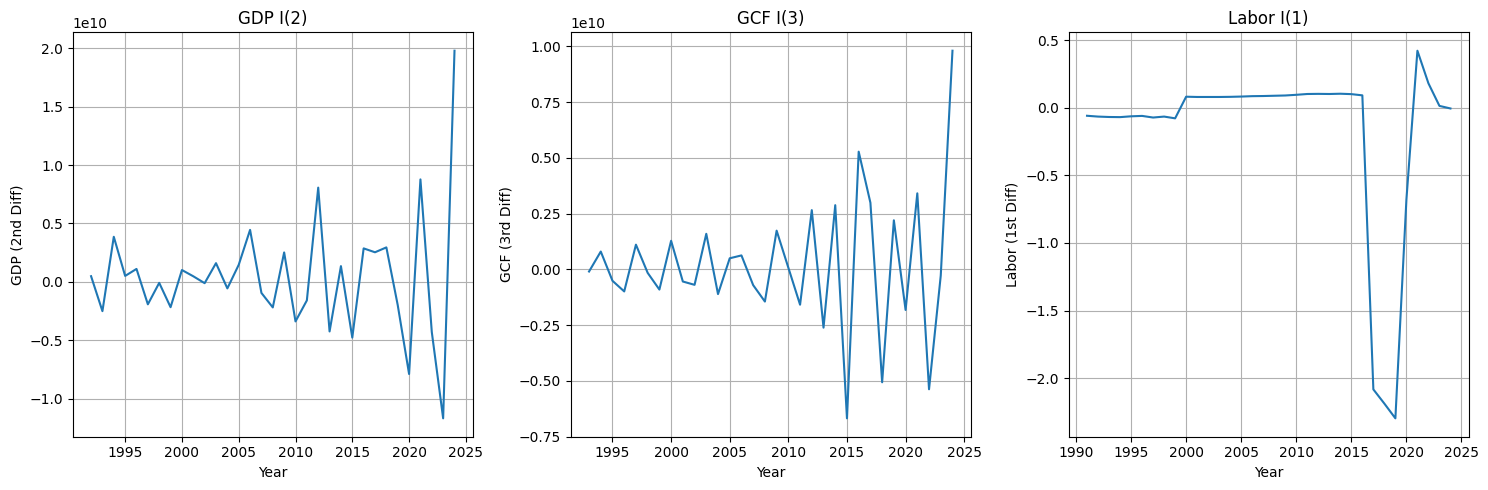

In [36]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(df['year'].loc[df_diff2.index], df_diff2)
plt.title('GDP I(2)')
plt.xlabel('Year')
plt.ylabel('GDP (2nd Diff)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(df['year'].loc[df_gcf_diff3.index], df_gcf_diff3)
plt.title('GCF I(3)')
plt.xlabel('Year')
plt.ylabel('GCF (3rd Diff)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(df['year'].loc[df_labor_diff.index], df_labor_diff)
plt.title('Labor I(1)')
plt.xlabel('Year')
plt.ylabel('Labor (1st Diff)')
plt.grid(True)

plt.tight_layout()
plt.show()

#**Fitting the ARIMA Model and Prediction for GDP**

Now that each variable have been differenced, an ARIMA model can now be fitted to the gdp series. Based on our stationarity tests, gdp requires a differencing order d=2. For the initial AutoRegressive (AR) order p and Moving Average (MA) order q, we will start with p=1 and q=1. These parameters can be further optimized using techniques like analyzing ACF/PACF plots or information criteria (AIC/BIC).

We will fit the ARIMA(1,2,1) model, make predictions, and visualize the results.

In [27]:
# Setting year as the index for time series modeling
df_indexed = df.set_index('year')

# Fitting ARIMA(p,d,q) model
# Using d=2 for gdp based on previous ADF tests
model = ARIMA(df_indexed['gdp'], order=(1, 2, 1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                    gdp   No. Observations:                   35
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -776.298
Date:                Sun, 07 Jun 2026   AIC                           1558.595
Time:                        09:30:33   BIC                           1563.085
Sample:                             0   HQIC                          1560.106
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1667      0.251     -0.665      0.506      -0.658       0.325
ma.L1         -0.7890      0.207     -3.817      0.000      -1.194      -0.384
sigma2      2.049e+19   3.58e-21   5.72e+39      0.0

######The Model Successfully addresses the non-stationarity of GDP by using 2 levels of differencing. The AR coefficient -0.1667 with a p-value of 0.506 suggests that the AR(1) term is not statistically significant in the model. The MA (1) coefficient -0.7890 with a p-value of 0.000, indicates a that the ma(1) term is statistically significant.


### **Making Predictions and Plotting Results**

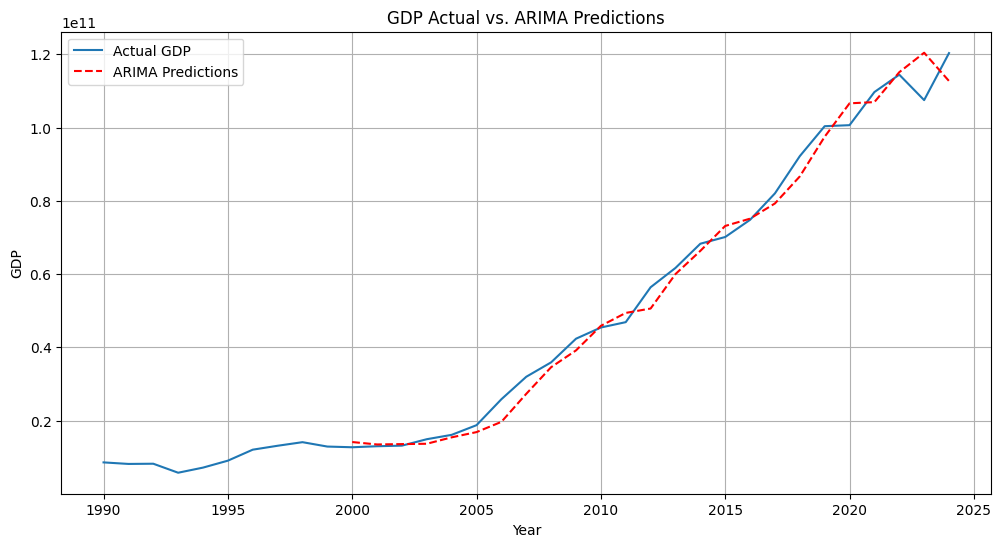

In [28]:
# Get the original length of the data
history_len = len(df_indexed['gdp'])

# Make predictions starting from a point in the observed data for comparison
# (e.g., from the year 2000 onwards for better visualization)
start_index = df_indexed.index.get_loc(2000)
predictions = model_fit.predict(start=start_index, end=history_len - 1, dynamic=False)

# Create a DataFrame for plotting
plot_df = df_indexed[['gdp']].copy()
plot_df['predictions'] = pd.Series(predictions, index=predictions.index)

plt.figure(figsize=(12, 6))
plt.plot(plot_df['gdp'], label='Actual GDP')
plt.plot(plot_df['predictions'], color='red', linestyle='--', label='ARIMA Predictions')
plt.title('GDP Actual vs. ARIMA Predictions')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()


####The plots shows that the ARIMA(1,2,1) model provides a reasonable fit for the general trend of GDP, but the prediction accuracy can be further improved by optimizing the p and q parameters.

#**Fitting the VARIMA Model for all Variables (GDP, GCF, Labor)**

To model all variables simultaneously, a VARIMA (Vector Autoregressive Integrated Moving Average) model is appropriate. Since the (statsmodels.tsa.api.VARIMA) class typically takes a single differencing order d for all series, we will use d=3, which is the highest differencing order required by any of our variables (GCF required d=3, GDP d=2, and Labor d=1).

**However, on Differencing Order (d):** Using d=3 for all series means that GDP and Labor will be over-differenced (as they only required d=2 and d=1 respectively). While this allows us to fit a VARIMA model directly using this API, it might not be the optimal approach if the individual differencing orders are vastly different and lead to over-differencing. More advanced multivariate models or custom differencing techniques could be explored for better performance. For this initial model, we will use p=1 and q=1 as starting values for the AR and MA components, respectively.

In [42]:
from statsmodels.tsa.api import VARMAX

# Manually differencing each series to its determined order
# GDP needs 2 differences (d=2)
# GCF needs 3 differences (d=3)
# Labor needs 1 difference (d=1)

gdp_diff2 = df_indexed['gdp'].diff().diff()
gcf_diff3 = df_indexed['gcf'].diff().diff().diff()
labor_diff1 = df_indexed['labor'].diff()

# Combine the differenced series into a new DataFrame
differenced_varima_data = pd.DataFrame({
    'gdp_diff2': gdp_diff2,
    'gcf_diff3': gcf_diff3,
    'labor_diff1': labor_diff1
}).dropna()

# Fit VARMAX(p,q) model to the already differenced data
# Since data is already differenced, 'd' (integration order) in VARMAX effectively becomes 0.
# We will try a simpler order=(1,0) (VAR(1) model) to address the LinAlgError.
# p=1, q=0 are initial guesses for the AR and MA components of the VARMA model.
varmax_model = VARMAX(differenced_varima_data, order=(1, 0))
varmax_model_fit = varmax_model.fit(disp=False)
print(varmax_model_fit.summary())

                                       Statespace Model Results                                      
Dep. Variable:     ['gdp_diff2', 'gcf_diff3', 'labor_diff1']   No. Observations:                   32
Model:                                                VAR(1)   Log Likelihood               -1498.115
                                                 + intercept   AIC                           3032.230
Date:                                       Sun, 07 Jun 2026   BIC                           3058.613
Time:                                               10:28:30   HQIC                          3040.975
Sample:                                                    0                                         
                                                        - 32                                         
Covariance Type:                                         opg                                         
Ljung-Box (L1) (Q):       3.16, 3.99, 3.44   Jarque-Bera (JB):    4.94, 2.73, 16.1

##**Making Predictions and Plotting Results for VARIMA Model**

Now, let's use the fitted VARIMA model to make predictions and visualize them against the actual values for GDP, GCF, and Labor.

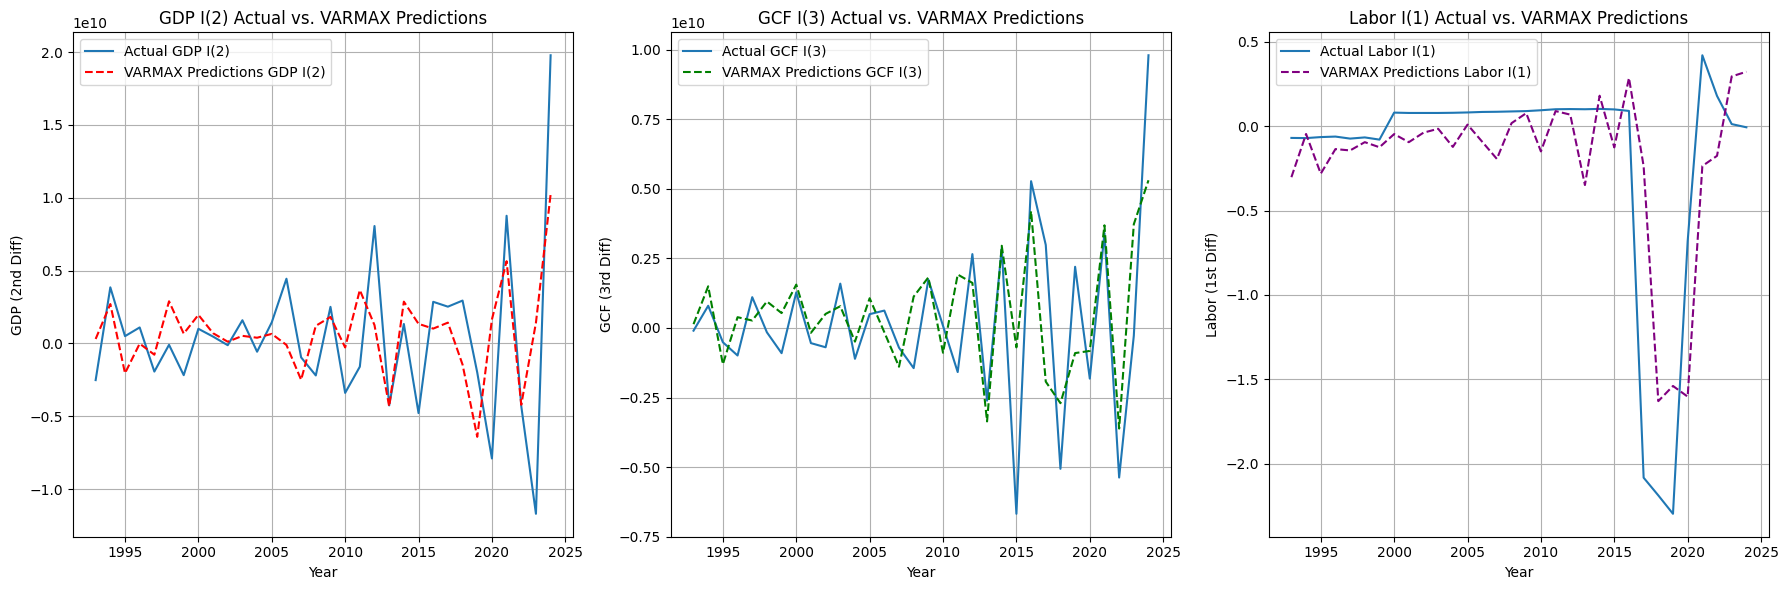

In [45]:
# Make predictions for the entire observed period on the differenced data
predictions_varmax = varmax_model_fit.predict(start=0, end=len(differenced_varima_data) - 1)

plt.figure(figsize=(18, 6))

# Plot GDP (2nd Differenced)
plt.subplot(1, 3, 1)
plt.plot(differenced_varima_data['gdp_diff2'], label='Actual GDP I(2)')
plt.plot(predictions_varmax['gdp_diff2'], color='red', linestyle='--', label='VARMAX Predictions GDP I(2)')
plt.title('GDP I(2) Actual vs. VARMAX Predictions')
plt.xlabel('Year')
plt.ylabel('GDP (2nd Diff)')
plt.legend()
plt.grid(True)

# Plot GCF (3rd Differenced)
plt.subplot(1, 3, 2)
plt.plot(differenced_varima_data['gcf_diff3'], label='Actual GCF I(3)')
plt.plot(predictions_varmax['gcf_diff3'], color='green', linestyle='--', label='VARMAX Predictions GCF I(3)')
plt.title('GCF I(3) Actual vs. VARMAX Predictions')
plt.xlabel('Year')
plt.ylabel('GCF (3rd Diff)')
plt.legend()
plt.grid(True)

# Plot Labor (1st Differenced)
plt.subplot(1, 3, 3)
plt.plot(differenced_varima_data['labor_diff1'], label='Actual Labor I(1)')
plt.plot(predictions_varmax['labor_diff1'], color='purple', linestyle='--', label='VARMAX Predictions Labor I(1)')
plt.title('Labor I(1) Actual vs. VARMAX Predictions')
plt.xlabel('Year')
plt.ylabel('Labor (1st Diff)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### *Interpretation of the Plotted Differenced Series*

The plots of the differenced series provide visual confirmation of the stationarity achieved after applying the appropriate differencing orders:

*   **GDP I(2) (Second-Differenced GDP):** This plot shows the GDP series after being differenced twice. Visually, the series now appears to fluctuate around a constant mean (close to zero) and a relatively constant variance. There are no obvious trends or seasonal patterns, suggesting that the second differencing step successfully removed the non-stationary components, aligning with the ADF test results.

*   **GCF I(3) (Third-Differenced GCF):** Similar to GDP, the GCF series, after being differenced three times, exhibits characteristics of a stationary series. The plot shows fluctuations without a clear upward or downward trend, and the variability appears consistent over time. This confirms that three differencing steps were necessary to achieve stationarity for GCF.

*   **Labor I(1) (First-Differenced Labor):** The plot of the first-differenced Labor series also suggests stationarity. The series oscillates around a relatively stable mean, and there isn't a discernible trend. This is consistent with the ADF test indicating that one differencing step was sufficient to make the Labor series stationary.

Overall, these plots visually reinforce the findings from the Augmented Dickey-Fuller tests, confirming that the respective differencing operations were effective in transforming the non-stationary economic indicator series into stationary ones, which is a prerequisite for fitting ARIMA-family models.